<h1 id="Lecture-2:-From-a-business-concern-to-an-answerable-question">Lecture 2: From a business concern to an answerable question</h1><p><strong>Concern:</strong> QuickBite wants more repeat orders.  <strong>Decision:</strong> should it test a new offer more widely?  <strong>Outcome:</strong> repeat order within 30 days.  <strong>Guardrail:</strong> delivery time and customer rating must not worsen.</p>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from ds301.paths import project_root
COURSE_ROOT = project_root()
TEAL, MINT, GOLD, CORAL, INK = "#005F73", "#0A9396", "#E9C46A", "#E76F51", "#1F2933"

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 120, "axes.titleweight": "bold", "axes.spines.top": False, "axes.spines.right": False})
orders = pd.read_csv(COURSE_ROOT / "data/quickbite_pilot.csv")
orders.groupby("offer_group")[["repeat_order_30d", "delivery_minutes", "rating"]].mean().round(3)

,repeat_order_30d,delivery_minutes,rating
offer_group,,,
comparison,0.148,27.753,3.031
new_offer,0.211,24.492,3.264


<h2 id="Begin-with-the-records">Begin with the records</h2><p>Each row is an eligible QuickBite customer in a pilot. First inspect the group label, outcome, and guardrails as recorded. Only then aggregate them into a group comparison. The display below keeps the raw unit visible before the summary chart.</p>

In [2]:
orders[["offer_group", "repeat_order_30d", "delivery_minutes", "rating"]].sample(10, random_state=301).sort_values("offer_group")

,offer_group,repeat_order_30d,delivery_minutes,rating
69,comparison,0,22.3,4.0
360,comparison,0,24.7,3.2
141,comparison,0,22.6,3.8
381,comparison,0,40.0,1.7
201,comparison,0,22.4,1.8
17,new_offer,1,20.6,3.2
228,new_offer,0,29.1,2.9
130,new_offer,1,19.9,4.0
91,new_offer,0,22.3,3.7
213,new_offer,0,26.7,3.3


<h2 id="Descriptive-evidence-is-not-a-prescription">Descriptive evidence is not a prescription</h2><p>A group comparison estimates the observed difference.  To make an action claim, check allocation, time period, costs, capacity, and who may be affected.</p>

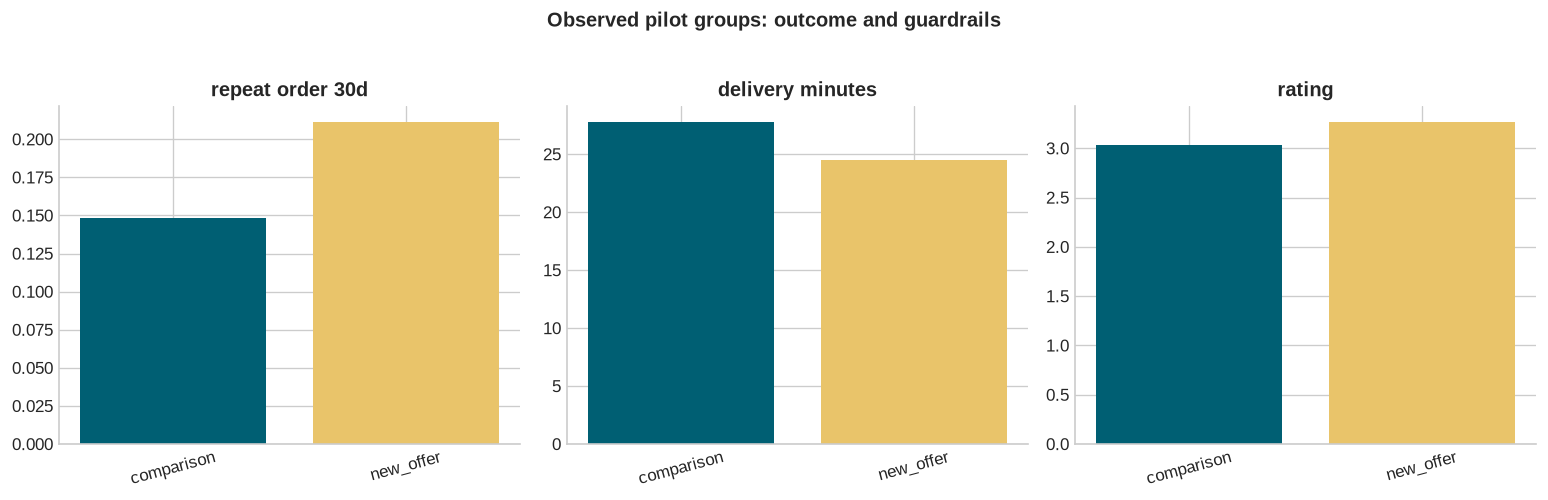

In [3]:
metrics = orders.groupby("offer_group")[["repeat_order_30d", "delivery_minutes", "rating"]].mean().T
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, metric in zip(axes, metrics.index):
    ax.bar(metrics.columns, metrics.loc[metric], color=[TEAL, GOLD])
    ax.set_title(metric.replace("_", " "))
    ax.tick_params(axis="x", rotation=15)
fig.suptitle("Observed pilot groups: outcome and guardrails", y=1.03, weight="bold")
plt.tight_layout()

In [4]:
observed = orders.groupby("offer_group")["repeat_order_30d"].mean()
effect = observed["new_offer"] - observed["comparison"]
print(f"Observed repeat-order difference: {effect:.1%}")

Observed repeat-order difference: 6.3%


<h2 id="Four-analytical-lenses">Four analytical lenses</h2><p>A useful project separates questions about facts, explanations, predictions, and choices. These questions connect, but they do not have the same evidence requirement.</p>

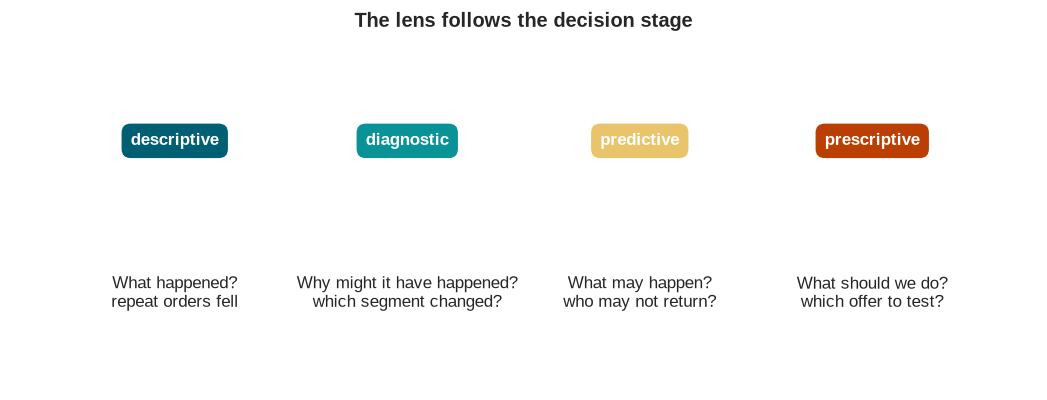

In [5]:
fig, ax=plt.subplots(figsize=(11,3.8))
lenses=[("descriptive","What happened?","repeat orders fell"),("diagnostic","Why might it have happened?","which segment changed?"),("predictive","What may happen?","who may not return?"),("prescriptive","What should we do?","which offer to test?")]
for i,(name,question,example) in enumerate(lenses):
    ax.text(i,.9,name,ha="center",color="white",weight="bold",bbox=dict(boxstyle="round,pad=.55",fc=[TEAL,"#0A9396",GOLD,"#BB3E03"][i],ec="none"))
    ax.text(i,.35,question+"\n"+example,ha="center",va="center")
ax.set(xlim=(-.7,3.7),ylim=(0,1.3),title="The lens follows the decision stage"); ax.axis("off")
plt.show()

<h2 id="Prediction-is-not-prescription">Prediction is not prescription</h2><p>A score can identify a group for review. A decision also needs feasible actions, cost, fairness, and an outcome to monitor.</p>

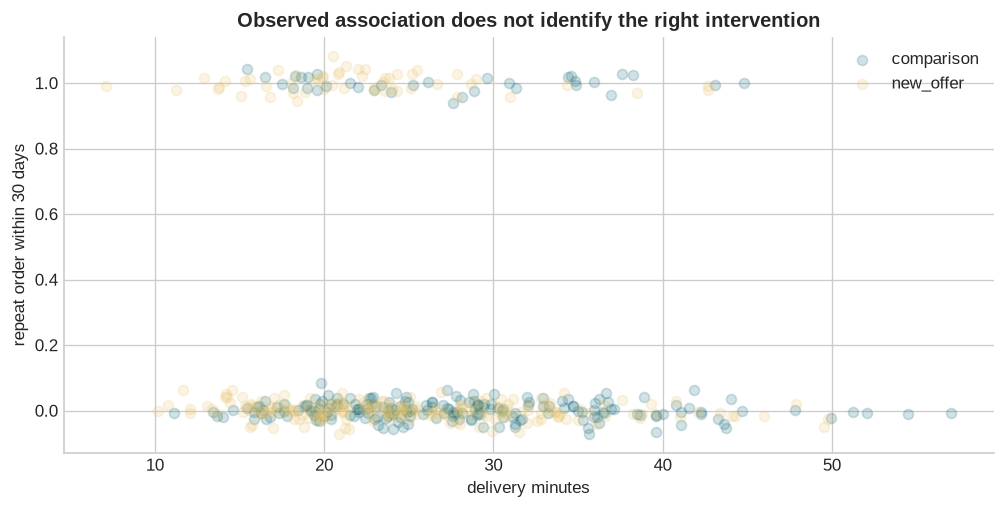

In [6]:
fig,ax=plt.subplots(figsize=(10,4.5))
for group,color in [("comparison",TEAL),("new_offer",GOLD)]:
    subset=orders.query("offer_group == @group")
    ax.scatter(subset.delivery_minutes+np.random.default_rng(2).normal(0,.15,len(subset)),subset.repeat_order_30d+np.random.default_rng(3).normal(0,.025,len(subset)),alpha=.18,c=color,label=group)
ax.set(xlabel="delivery minutes",ylabel="repeat order within 30 days",title="Observed association does not identify the right intervention")
ax.legend(); plt.show()

<h2 id="Correlation-is-not-causation">Correlation is not causation</h2><p>A third factor can move both variables. A controlled experiment or a credible causal design is needed before claiming that changing one variable will cause the outcome to change.</p>

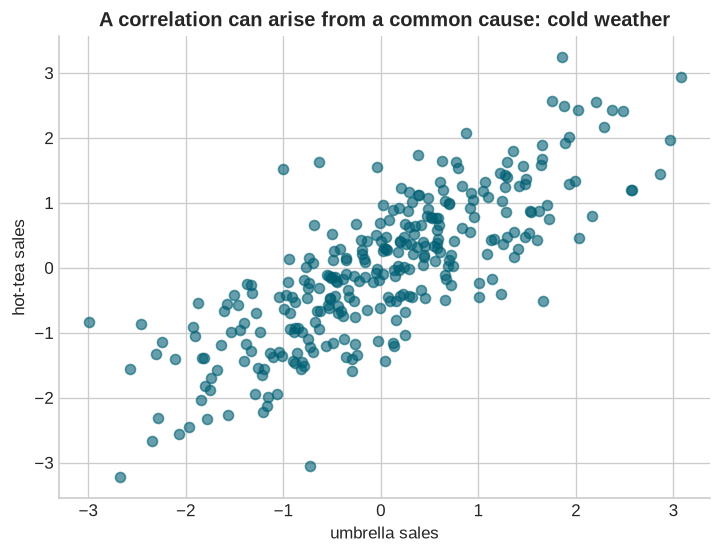

In [7]:
rng=np.random.default_rng(22); weather=rng.normal(size=300); umbrellas=weather+rng.normal(0,.5,300); tea=weather+rng.normal(0,.5,300)
fig,ax=plt.subplots(figsize=(7,5)); ax.scatter(umbrellas,tea,c=TEAL,alpha=.6)
ax.set(xlabel="umbrella sales",ylabel="hot-tea sales",title="A correlation can arise from a common cause: cold weather")
plt.show()

<h2 id="Frame-the-decision-before-selecting-data">Frame the decision before selecting data</h2><p>A useful question makes five parts visible: decision-maker, available choice, outcome, unit and time horizon, and constraints. The table is a decision canvas, not a list of columns to collect.</p>

In [8]:
canvas = pd.DataFrame({
    "part": ["decision-maker", "decision", "outcome", "unit and horizon", "constraints"],
    "QuickBite example": [
        "regional operations lead",
        "extend, revise, or stop an offer pilot",
        "repeat order within 30 days",
        "one eligible customer; next 30 days",
        "budget, delivery capacity, fairness, consent",
    ],
    "question to settle": [
        "Who is accountable for the choice?",
        "Which actions are genuinely feasible?",
        "What would count as improvement?",
        "For whom and by when?",
        "What may not be traded away?",
    ],
})
canvas

,part,QuickBite example,question to settle
0,decision-maker,regional operations lead,Who is accountable for the choice?
1,decision,"extend, revise, or stop an offer pilot",Which actions are genuinely feasible?
2,outcome,repeat order within 30 days,What would count as improvement?
3,unit and horizon,one eligible customer; next 30 days,For whom and by when?
4,constraints,"budget, delivery capacity, fairness, consent",What may not be traded away?


<h2 id="Metric,-KPI,-and-decision-rule-play-different-roles">Metric, KPI, and decision rule play different roles</h2><p>A metric measures; a KPI ties a measure to an important goal; a decision rule states how evidence changes a next step. The same measure can be informative without being a good decision rule.</p>

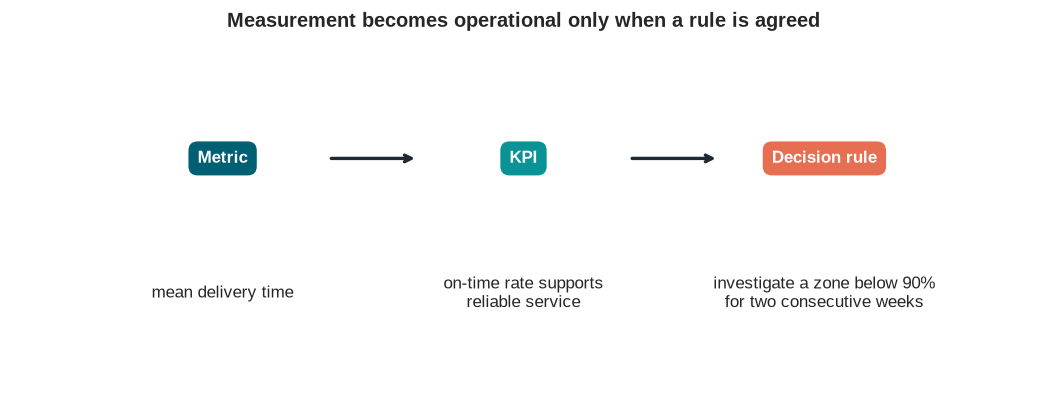

In [9]:
fig, ax = plt.subplots(figsize=(11, 3.8))
chain = [
    ("Metric", "mean delivery time", TEAL),
    ("KPI", "on-time rate supports\nreliable service", MINT),
    ("Decision rule", "investigate a zone below 90%\nfor two consecutive weeks", CORAL),
]
for i, (name, example, colour) in enumerate(chain):
    ax.text(i, .85, name, ha="center", va="center", color="white", weight="bold",
            bbox=dict(boxstyle="round,pad=.55", fc=colour, ec="none"))
    ax.text(i, .35, example, ha="center", va="center")
    if i < 2:
        ax.annotate("", (i + .65, .85), (i + .35, .85), arrowprops=dict(arrowstyle="->", lw=2, color=INK))
ax.set(xlim=(-.7, 2.7), ylim=(0, 1.3), title="Measurement becomes operational only when a rule is agreed")
ax.axis("off")
plt.show()

<h2 id="Leading-and-lagging-evidence">Leading and lagging evidence</h2><p>A lagging measure confirms an outcome after it happens. A leading signal may give earlier warning, but it still needs validation before it becomes a target or a trigger.</p>

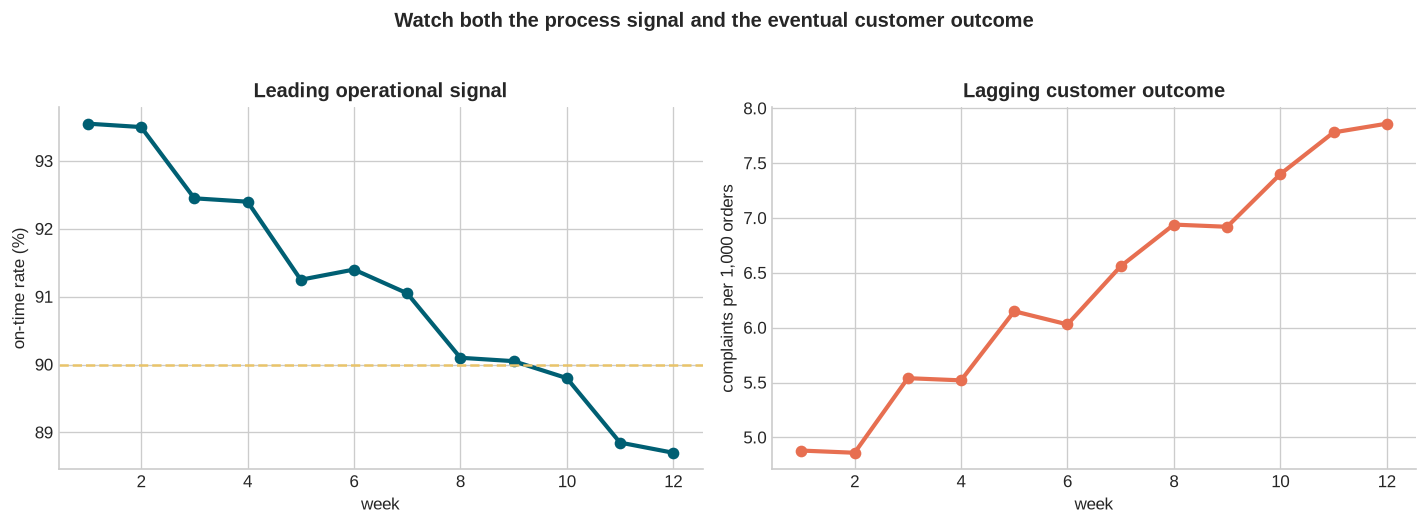

In [10]:
weeks = np.arange(1, 13)
on_time = 94 - .45 * weeks + np.array([0,.4,-.2,.2,-.5,.1,.2,-.3,.1,.3,-.2,.1])
complaints = 4.5 + .28 * weeks + np.array([.1,-.2,.2,-.1,.25,-.15,.1,.2,-.1,.1,.2,0])
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharex=True)
axes[0].plot(weeks, on_time, "o-", color=TEAL, lw=2.5); axes[0].axhline(90, color=GOLD, ls="--")
axes[0].set(title="Leading operational signal", xlabel="week", ylabel="on-time rate (%)")
axes[1].plot(weeks, complaints, "o-", color=CORAL, lw=2.5)
axes[1].set(title="Lagging customer outcome", xlabel="week", ylabel="complaints per 1,000 orders")
fig.suptitle("Watch both the process signal and the eventual customer outcome", weight="bold", y=1.03)
plt.tight_layout()

<h2 id="Feasibility-check-before-analysis">Feasibility check before analysis</h2><p>A sophisticated answer is not useful if the action cannot be taken. Check the evidence, decision authority, capacity, timing, and possible harm before promising a project.</p>

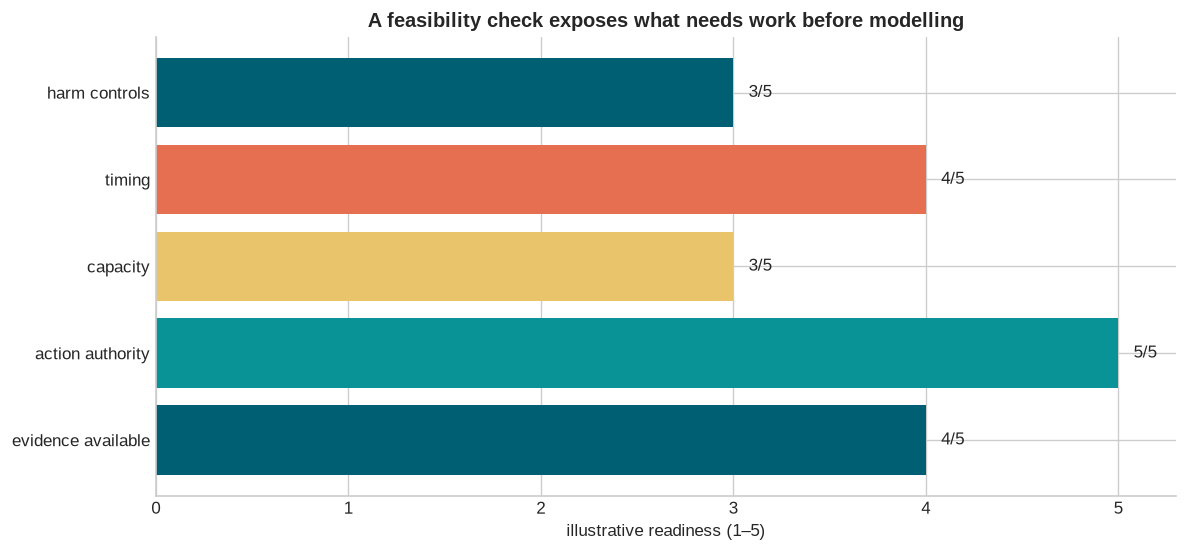

In [11]:
fig, ax = plt.subplots(figsize=(10, 4.7))
criteria = pd.Series({"evidence available": 4, "action authority": 5, "capacity": 3, "timing": 4, "harm controls": 3})
ax.barh(criteria.index, criteria.values, color=[TEAL, MINT, GOLD, CORAL, TEAL])
ax.set(xlim=(0, 5.3), xlabel="illustrative readiness (1–5)", title="A feasibility check exposes what needs work before modelling")
for y, value in enumerate(criteria.values): ax.text(value + .08, y, f"{value}/5", va="center")
plt.tight_layout()

<h3 id="Student-activity">Student activity</h3><p>Rewrite “our marketing is ineffective” as one descriptive, one diagnostic, one predictive, and one prescriptive question.  For the prescriptive question, state an action, a metric, and one constraint.</p>

<h2 id="Applied-framing-lab:-diagnostic-classification">Applied framing lab: diagnostic classification</h2><p>The breast-cancer diagnostic dataset is bundled with scikit-learn. It supports a compact illustration of framing, not clinical use. The prediction question is deliberately narrow: can measurements help distinguish the recorded diagnostic class on held-out records?</p>

In [12]:
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

cancer = load_breast_cancer(as_frame=True)
frame = cancer.frame.assign(diagnosis=np.where(cancer.target == 1, "benign", "malignant"))
frame[["mean radius", "mean texture", "diagnosis"]].head(8)

,mean radius,mean texture,diagnosis
0,17.99,10.38,malignant
1,20.57,17.77,malignant
2,19.69,21.25,malignant
3,11.42,20.38,malignant
4,20.29,14.34,malignant
5,12.45,15.70,malignant
6,18.25,19.98,malignant
7,13.71,20.83,malignant


<p><strong>Raw records first.</strong> The two measurements overlap across the recorded classes. That overlap makes the outcome, error costs, and evaluation plan part of the problem framing.</p>

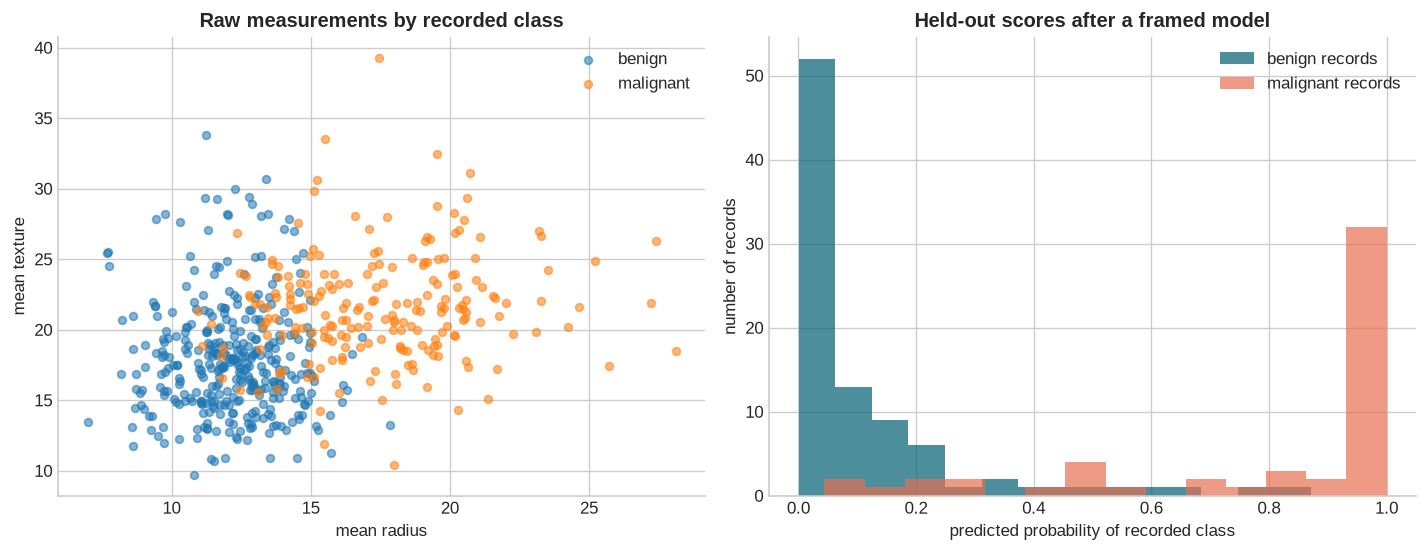

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.7))
for label, group in frame.groupby("diagnosis"):
    axes[0].scatter(group["mean radius"], group["mean texture"], s=22, alpha=.55, label=label)
axes[0].set(title="Raw measurements by recorded class", xlabel="mean radius", ylabel="mean texture"); axes[0].legend()
X = frame[["mean radius", "mean texture"]]; y = (frame.diagnosis == "malignant").astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=.25, random_state=301)
classifier = make_pipeline(StandardScaler(), LogisticRegression()).fit(X_train, y_train)
score = classifier.predict_proba(X_test)[:, 1]
axes[1].hist(score[y_test.to_numpy()==0], bins=14, alpha=.7, color=TEAL, label="benign records")
axes[1].hist(score[y_test.to_numpy()==1], bins=14, alpha=.7, color=CORAL, label="malignant records")
axes[1].set(title="Held-out scores after a framed model", xlabel="predicted probability of recorded class", ylabel="number of records"); axes[1].legend()
plt.tight_layout()

<p>A deployment question would require a validated outcome definition, a suitable population, calibrated probabilities, clinician oversight, and an explicit policy for both kinds of error.</p>

### Lecture application

Write the unit, target, prediction moment, success measure, review capacity and guardrail before running the model. Distinguish the predictive question from a claim about what causes a cultivar.

## Worked project: identifying wine cultivars from measured chemistry

**Question:** can chemical measurements identify the recorded cultivar of an unseen wine sample? The UCI Wine Recognition dataset has 178 measured samples, 13 input features and three cultivar labels. A laboratory could use such a model as a screening aid. This small historical sample cannot establish performance on every producer or future vintage.

We will inspect rows and units, reserve test records, establish a majority-class baseline, select a model using training folds, inspect errors, and write a decision statement. The class label is the outcome, so it never enters the feature matrix. No download is required because scikit-learn bundles these observations.

In [14]:
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, ConfusionMatrixDisplay
project_data = load_wine(as_frame=True)
project_X, project_y = project_data.data, project_data.target
display(project_data.frame.head(8))
display(pd.DataFrame({'dtype':project_X.dtypes.astype(str), 'missing':project_X.isna().sum(),
                      'minimum':project_X.min(), 'maximum':project_X.max()}).round(3))

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
5,14.20,1.76,2.45,15.2,112.0,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450.0,0
6,14.39,1.87,2.45,14.6,96.0,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290.0,0
7,14.06,2.15,2.61,17.6,121.0,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295.0,0


,dtype,missing,minimum,maximum
alcohol,float64,0,11.03,14.83
malic_acid,float64,0,0.74,5.80
ash,float64,0,1.36,3.23
alcalinity_of_ash,float64,0,10.60,30.00
magnesium,float64,0,70.00,162.00
total_phenols,float64,0,0.98,3.88
flavanoids,float64,0,0.34,5.08
nonflavanoid_phenols,float64,0,0.13,0.66
proanthocyanins,float64,0,0.41,3.58
color_intensity,float64,0,1.28,13.00


### Inspect the observations before choosing a model

The scatter compares two recorded features. The counts show how many examples represent each class. A two-feature view may hide separation present in the other measurements. A random stratified split assumes that these records represent the unseen samples of interest; new producers or later vintages would need a different evaluation design.

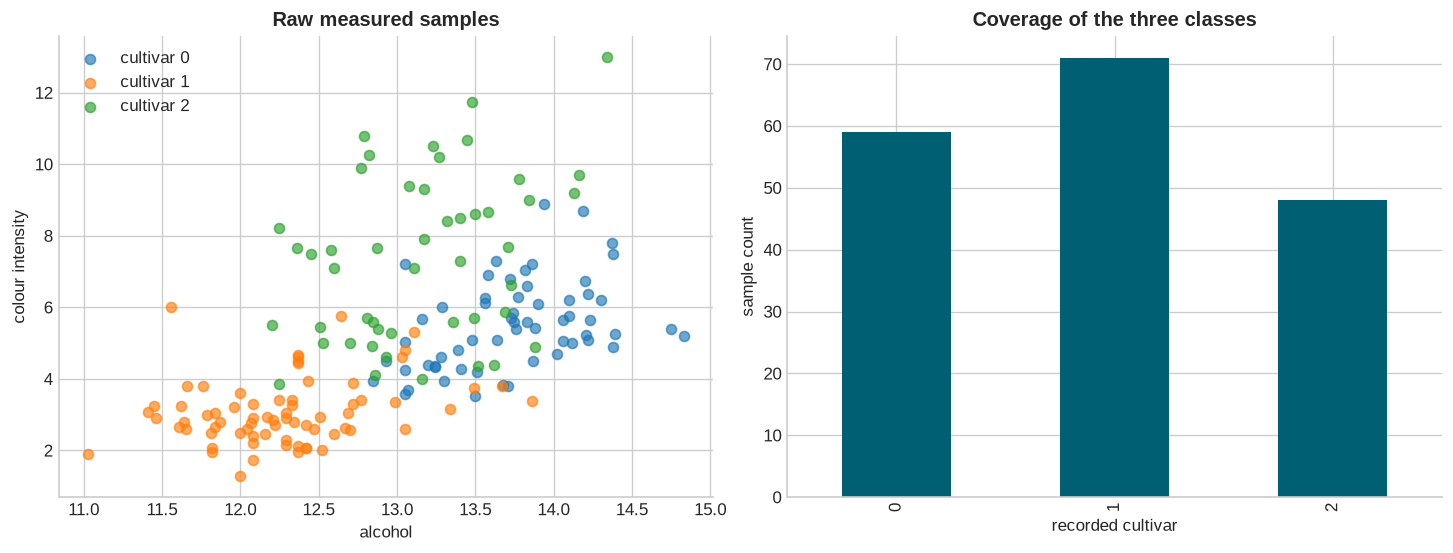

In [15]:
fig, axes = plt.subplots(1,2,figsize=(12,4.5),layout='constrained')
for label in np.unique(project_y):
    selected = project_y==label
    axes[0].scatter(project_X.loc[selected,'alcohol'],project_X.loc[selected,'color_intensity'],label=f'cultivar {label}',alpha=.65)
axes[0].set(xlabel='alcohol',ylabel='colour intensity',title='Raw measured samples'); axes[0].legend()
project_y.value_counts().sort_index().plot.bar(ax=axes[1],color='#005F73')
axes[1].set(xlabel='recorded cultivar',ylabel='sample count',title='Coverage of the three classes'); plt.show()
project_train, project_test, target_train, target_test = train_test_split(project_X,project_y,test_size=.25,stratify=project_y,random_state=301)

### Fit a baseline, then select a model using training folds

The baseline always predicts the most common training class. The learned model scales features inside each training fold and estimates logistic probabilities. The validation table selects the regularisation setting using only training data. `C` is inverse regularisation strength: a smaller value applies stronger shrinkage.

,C,validation balanced accuracy,fold SD
0,0.01,0.981,0.026
1,0.10,0.981,0.026
2,1.00,0.972,0.026
3,10.00,0.964,0.022


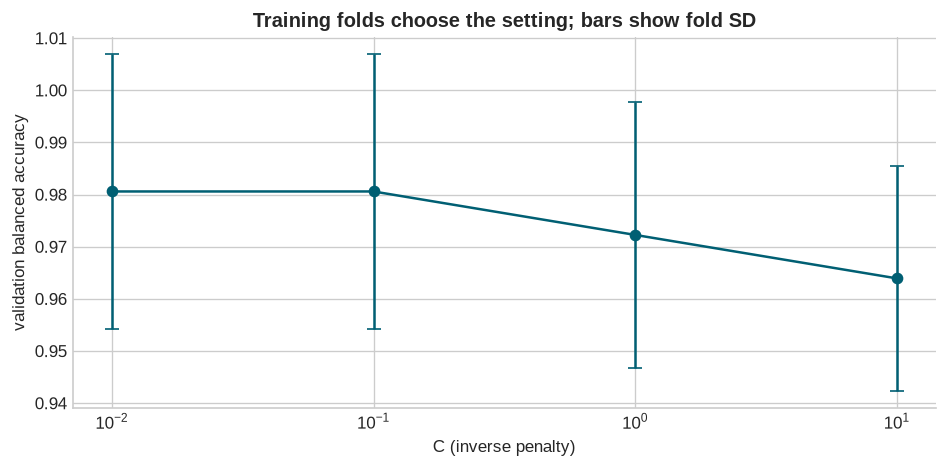

In [16]:
project_baseline = DummyClassifier(strategy='most_frequent').fit(project_train,target_train)
project_cv = StratifiedKFold(5,shuffle=True,random_state=301)
project_search = GridSearchCV(make_pipeline(StandardScaler(),LogisticRegression(max_iter=2000)),
                             {'logisticregression__C':[.01,.1,1,10]},cv=project_cv,scoring='balanced_accuracy')
project_search.fit(project_train,target_train)
cv_table = pd.DataFrame(project_search.cv_results_)[['param_logisticregression__C','mean_test_score','std_test_score']]
display(cv_table.rename(columns={'param_logisticregression__C':'C','mean_test_score':'validation balanced accuracy','std_test_score':'fold SD'}).round(3))
fig,ax=plt.subplots(figsize=(8,4))
ax.errorbar(cv_table.iloc[:,0].astype(float),cv_table.iloc[:,1],yerr=cv_table.iloc[:,2],fmt='o-',capsize=4,color='#005F73')
ax.set(xscale='log',xlabel='C (inverse penalty)',ylabel='validation balanced accuracy',title='Training folds choose the setting; bars show fold SD')
plt.tight_layout(); plt.show()

### Open the held-out set once and inspect the errors

The confusion matrix counts actual outcomes, rather than compressing every error into one score. Each row refers to the true cultivar. Off-diagonal cells show which classes the fitted model confuses. These counts are small, so a high score on this split has substantial sampling uncertainty.

,model,test accuracy,test balanced accuracy
0,majority baseline,0.4,0.333
1,selected logistic model,1.0,1.000


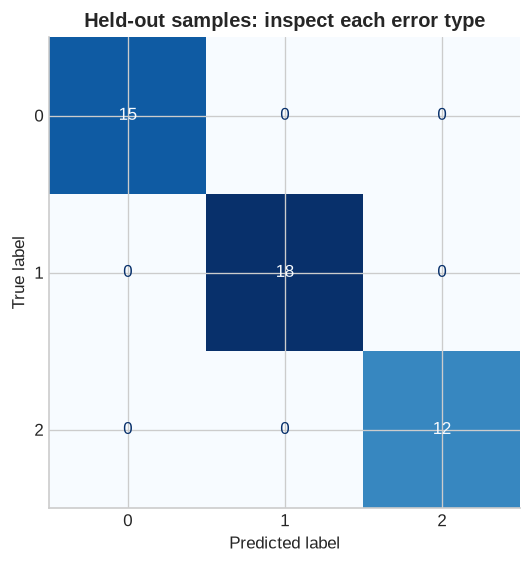

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,observed cultivar,predicted cultivar,highest probability
43,13.24,3.98,2.29,17.5,103.0,2.64,2.63,0.32,1.66,4.36,0.82,3.00,680.0,0,0,0.410
130,12.86,1.35,2.32,18.0,122.0,1.51,1.25,0.21,0.94,4.10,0.76,1.29,630.0,2,2,0.436
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,0,0.490
118,12.77,3.43,1.98,16.0,80.0,1.63,1.25,0.43,0.83,3.40,0.70,2.12,372.0,1,1,0.509
96,11.81,2.12,2.74,21.5,134.0,1.60,0.99,0.14,1.56,2.50,0.95,2.26,625.0,1,1,0.537
121,11.56,2.05,3.23,28.5,119.0,3.18,5.08,0.47,1.87,6.00,0.93,3.69,465.0,1,1,0.540
65,12.37,1.21,2.56,18.1,98.0,2.42,2.65,0.37,2.08,4.60,1.19,2.30,678.0,1,1,0.554
71,13.86,1.51,2.67,25.0,86.0,2.95,2.86,0.21,1.87,3.38,1.36,3.16,410.0,1,1,0.555


In [17]:
project_pred = project_search.predict(project_test)
baseline_pred = project_baseline.predict(project_test)
display(pd.DataFrame({'model':['majority baseline','selected logistic model'],
                      'test accuracy':[accuracy_score(target_test,baseline_pred),accuracy_score(target_test,project_pred)],
                      'test balanced accuracy':[balanced_accuracy_score(target_test,baseline_pred),balanced_accuracy_score(target_test,project_pred)]}).round(3))
fig,ax=plt.subplots(figsize=(6,4.8))
ConfusionMatrixDisplay.from_predictions(target_test,project_pred,ax=ax,cmap='Blues',colorbar=False)
ax.set_title('Held-out samples: inspect each error type'); plt.tight_layout(); plt.show()
project_review=project_test.copy()
project_review['observed cultivar']=target_test
project_review['predicted cultivar']=project_pred
project_review['highest probability']=project_search.predict_proba(project_test).max(axis=1)
display(project_review.sort_values('highest probability').head(8).round(3))

### Decision statement and next evidence

Compare the selected model with the baseline using the table above. State the held-out sample size and the errors you see. A laboratory would next validate new samples from its own measurement process and agree when a prediction requires manual review. Monitoring would track missing measurements, feature ranges, class frequencies, and verified errors. Confidence scores need calibration evidence before they can justify an automatic acceptance threshold.